In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

In [5]:
INPUT_FILE = "/Users/oussamanair/Downloads/stage/paris_morphological_features.csv"

print("Loading feature dataset...")

df = pd.read_csv(INPUT_FILE)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")




Loading feature dataset...
Rows: 42,197
Columns: 38


In [17]:
features = [
    "min_raylen2D",
    "avg_raylen2D",
    "med_raylen2D",
    "drift_raylen2D",
    "H_raylen2D",
    "avg_raylen25D",
    "svf_geom",
    "isovist_area",
    "isovist_perimeter",
    "streetlight_count"
]
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["period"].isin(["day", "night"])].copy()

df[features].isna().sum()

min_raylen2D         0
avg_raylen2D         0
med_raylen2D         0
drift_raylen2D       0
H_raylen2D           0
avg_raylen25D        0
svf_geom             0
isovist_area         0
isovist_perimeter    0
streetlight_count    0
dtype: int64

In [18]:
trajectory_features = (
    df
    .groupby(["trace_id", "period"])[features]
    .agg(["mean", "median", "std", "min", "max"])
)

trajectory_features.columns = [
    f"{feature}_{stat}"
    for feature, stat in trajectory_features.columns
]

trajectory_features = trajectory_features.reset_index()

trajectory_features.shape

(685, 52)

In [8]:
trajectory_features.head()

,trace_id,period,min_raylen2D_mean,min_raylen2D_median,min_raylen2D_std,min_raylen2D_min,min_raylen2D_max,avg_raylen2D_mean,avg_raylen2D_median,avg_raylen2D_std,...,isovist_perimeter_mean,isovist_perimeter_median,isovist_perimeter_std,isovist_perimeter_min,isovist_perimeter_max,streetlight_count_mean,streetlight_count_median,streetlight_count_std,streetlight_count_min,streetlight_count_max
0,trace_004d417a-6786-43f8-bcab-bf869cf0d1f0.gpx,day,29.624110,30.394293,4.387231,21.045588,33.749223,77.958537,78.427276,2.828455,...,583.120358,581.775580,4.490184,578.979731,592.777500,57.857143,52.0,12.979838,49,84
1,trace_011d62c5-454d-491c-b174-8078cd9abbfe.gpx,night,26.775497,26.177232,9.766976,4.059889,41.723183,65.268732,65.928839,3.445135,...,831.000437,846.630158,59.110950,642.089601,914.130829,47.263158,47.0,2.104020,43,52
2,trace_016c5b7c-8380-458e-8d1a-4e507293c415.gpx,night,25.646774,26.325104,14.055782,6.331786,85.376729,81.471415,81.787291,6.832738,...,706.245052,706.864350,47.578027,566.565593,961.117916,121.701299,121.0,14.275545,66,220
3,trace_0174e322-984f-42e3-a165-bc6388b4e74a.gpx,day,8.343467,6.591583,5.511198,1.029882,18.727687,44.146240,42.961157,5.096390,...,657.026875,655.754552,83.599502,484.367056,785.754902,13.576923,14.0,1.942639,8,16
4,trace_01c17623-b8d2-45b0-88fd-042acd5cd3be.gpx,day,5.045891,4.496218,2.704535,0.796506,12.234492,23.336973,24.053521,4.995390,...,573.802797,578.194349,141.611447,253.936573,811.368961,17.000000,16.0,7.324415,6,33


In [19]:
trajectory_features["period"].value_counts()

period
day      600
night     85
Name: count, dtype: int64

In [20]:
mean_features = (
    trajectory_features
    .groupby("period")
    .mean(numeric_only=True)
)

mean_features.T

period,day,night
min_raylen2D_mean,24.005981,17.653923
min_raylen2D_median,22.710046,16.621782
min_raylen2D_std,11.307313,10.486512
min_raylen2D_min,8.345351,3.233345
min_raylen2D_max,47.606074,41.607465
avg_raylen2D_mean,60.999595,53.271875
avg_raylen2D_median,61.394556,54.550586
avg_raylen2D_std,10.800427,12.163152
avg_raylen2D_min,39.178906,28.826090
avg_raylen2D_max,77.591039,71.879605


In [21]:
median_features = (
    trajectory_features
    .groupby("period")
    .median(numeric_only=True)
)

median_features.T

period,day,night
min_raylen2D_mean,16.112904,11.600420
min_raylen2D_median,13.319704,9.793387
min_raylen2D_std,8.455583,7.492946
min_raylen2D_min,1.810652,1.169644
min_raylen2D_max,39.251167,31.555269
avg_raylen2D_mean,63.326849,50.874413
avg_raylen2D_median,64.199932,50.399524
avg_raylen2D_std,9.362259,11.138481
avg_raylen2D_min,32.414035,23.671288
avg_raylen2D_max,83.387751,73.722755


In [22]:
stats = []

for feature in features:

    col = f"{feature}_mean"

    day = trajectory_features.loc[
        trajectory_features["period"] == "day",
        col
    ].dropna()

    night = trajectory_features.loc[
        trajectory_features["period"] == "night",
        col
    ].dropna()

    stat, p = mannwhitneyu(
        day,
        night,
        alternative="two-sided"
    )

    stats.append({
        "feature": feature,
        "day_median": day.median(),
        "night_median": night.median(),
        "day_mean": day.mean(),
        "night_mean": night.mean(),
        "p_value": p
    })

stats_df = pd.DataFrame(stats)

stats_df.sort_values("p_value")

,feature,day_median,night_median,day_mean,night_mean,p_value
6,svf_geom,0.698620,0.568312,0.665115,0.585150,0.002917
4,H_raylen2D,2.423817,2.756299,2.145513,2.428320,0.004435
2,med_raylen2D,68.284488,47.322917,63.403219,53.676750,0.006324
5,avg_raylen25D,64.115070,52.993174,61.824720,54.107065,0.007772
1,avg_raylen2D,63.326849,50.874413,60.999595,53.271875,0.008117
8,isovist_perimeter,656.959797,635.836452,642.875963,620.164580,0.008461
7,isovist_area,16362.196890,11699.471612,16095.120181,13243.890989,0.008578
3,drift_raylen2D,14.648550,16.216345,14.986775,17.119251,0.027249
0,min_raylen2D,16.112904,11.600420,24.005981,17.653923,0.044869
9,streetlight_count,30.546070,34.174603,55.274084,56.876967,0.062747


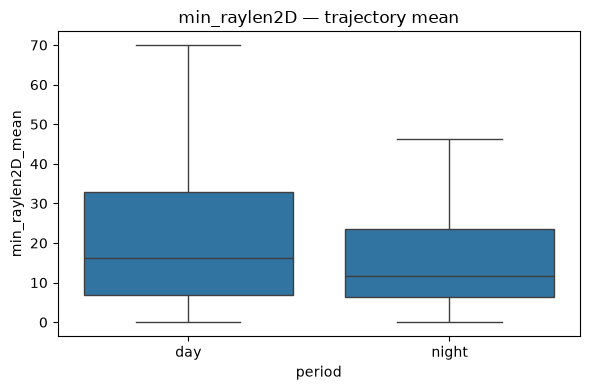

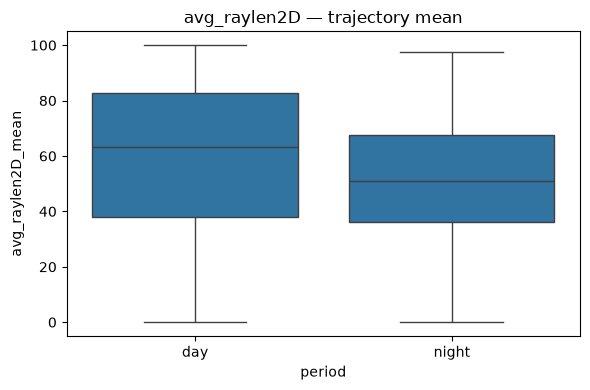

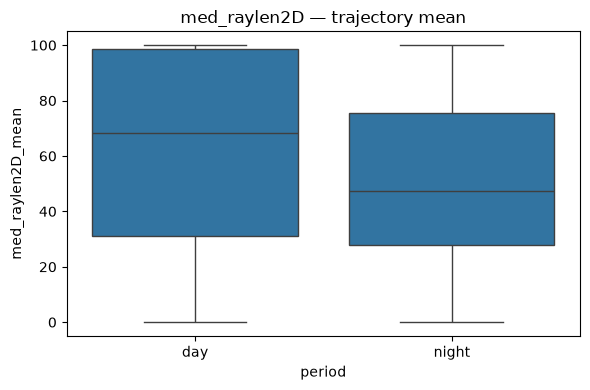

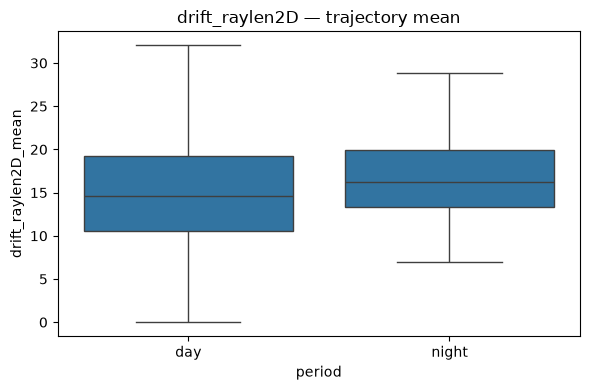

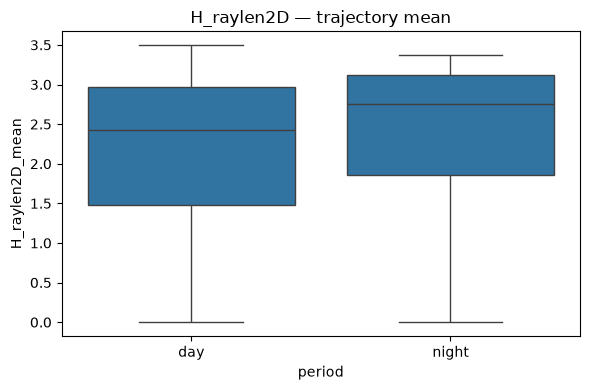

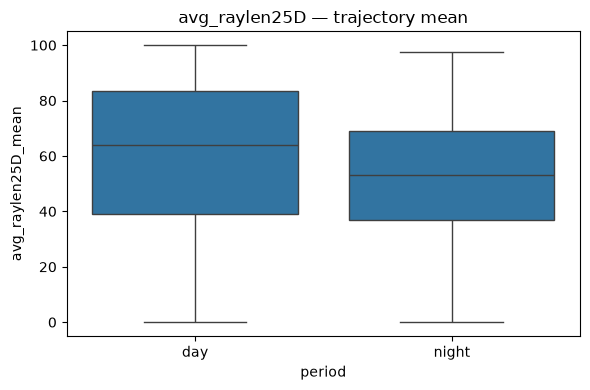

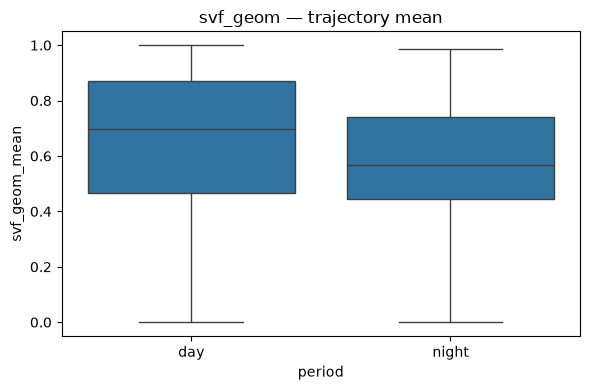

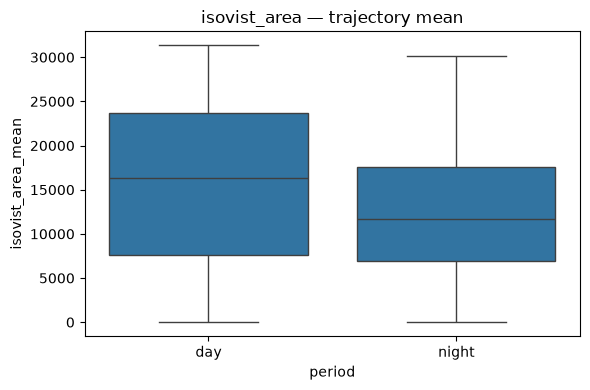

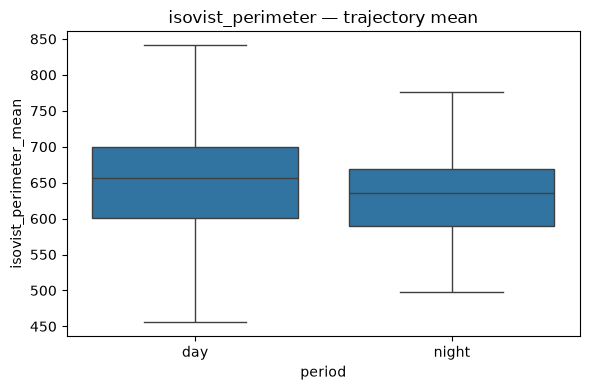

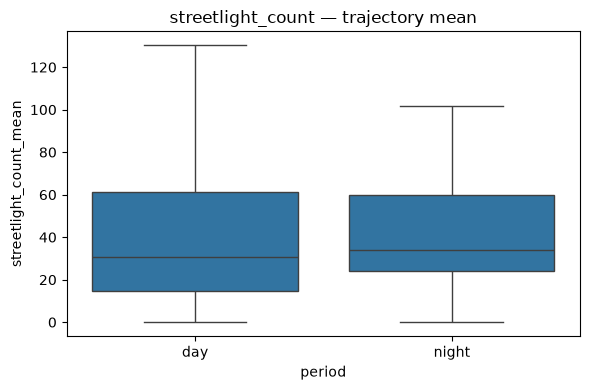

In [23]:
for feature in features:

    col = f"{feature}_mean"

    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=trajectory_features,
        x="period",
        y=col,
        showfliers=False
    )

    plt.title(f"{feature} — trajectory mean")
    plt.tight_layout()
    plt.show()

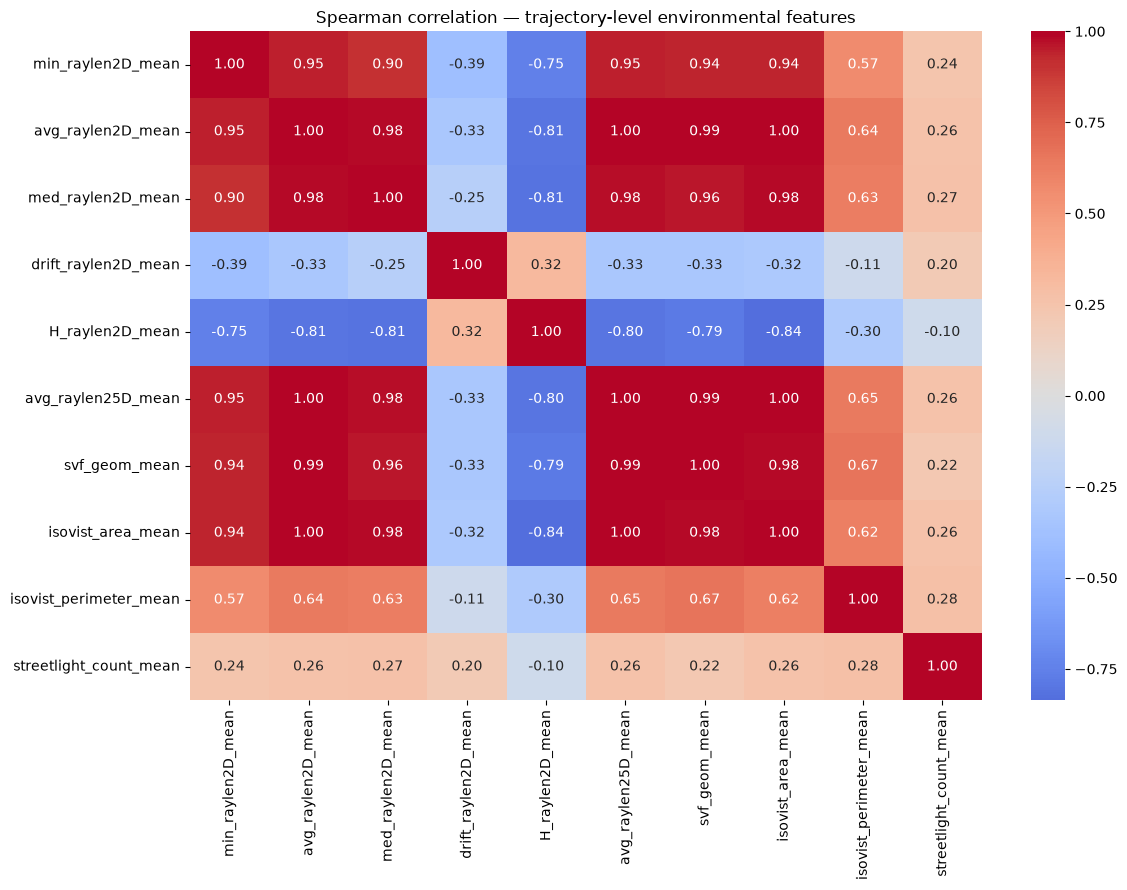

In [24]:
mean_cols = [
    f"{f}_mean"
    for f in features
]

corr = (
    trajectory_features[mean_cols]
    .corr(method="spearman")
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title(
    "Spearman correlation — trajectory-level environmental features"
)

plt.tight_layout()
plt.show()

PC1 explained variance: 0.6914143842550893
PC2 explained variance: 0.13067614355807097


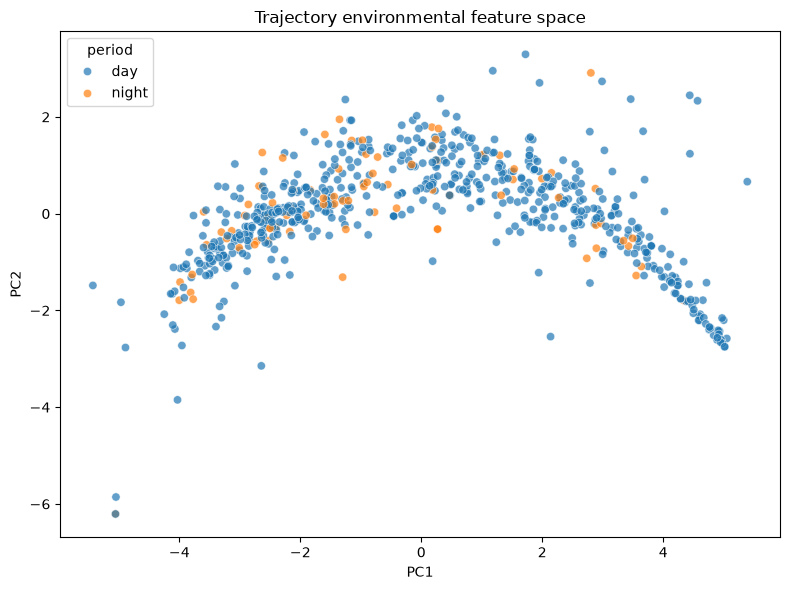

In [25]:
X = trajectory_features[
    mean_cols
].copy()

y = trajectory_features["period"]
valid = X.notna().all(axis=1)

X = X.loc[valid]
y = y.loc[valid]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "PC1 explained variance:",
    pca.explained_variance_ratio_[0]
)

print(
    "PC2 explained variance:",
    pca.explained_variance_ratio_[1]
)
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "period": y.values
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="period",
    alpha=0.7
)

plt.title("Trajectory environmental feature space")
plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [27]:
features = [
    "min_raylen2D",
    "avg_raylen2D",
    "med_raylen2D",
    "drift_raylen2D",
    "H_raylen2D",
    "avg_raylen25D",
    "svf_geom",
    "isovist_area",
    "isovist_perimeter",
    "streetlight_count"
]

feature_cols = [
    f"{feature}_mean"
    for feature in features
]

clf_df = trajectory_features[
    ["trace_id", "period"] + feature_cols
].copy()

# Remove invalid values
clf_df[feature_cols] = clf_df[feature_cols].replace(
    [np.inf, -np.inf],
    np.nan
)

clf_df = clf_df.dropna(
    subset=feature_cols + ["period"]
)

print("Shape:", clf_df.shape)
print("\nClasses:")
print(clf_df["period"].value_counts())

Shape: (685, 12)

Classes:
period
day      600
night     85
Name: count, dtype: int64


In [28]:
X = clf_df[feature_cols]

y = (
    clf_df["period"]
    .map({
        "day": 0,
        "night": 1
    })
)

print(X.shape)
print(y.value_counts())

(685, 10)
period
0    600
1     85
Name: count, dtype: int64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (513, 10)
Testing: (172, 10)


In [30]:
model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['min_raylen2D_mean','avg_raylen2D_mean','med_raylen2D_mean',..., 'isovist_area_mean','isovist_perimeter_mean','streetlight_count_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [31]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["day", "night"]
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         day       0.91      0.57      0.70       151
       night       0.17      0.62      0.26        21

    accuracy                           0.58       172
   macro avg       0.54      0.59      0.48       172
weighted avg       0.82      0.58      0.65       172

ROC-AUC: 0.5938189845474613

Confusion matrix:
[[86 65]
 [ 8 13]]
